In [1]:
from google.colab import files
uploaded = files.upload()

Saving DII_Dataset_1550_records.xlsx to DII_Dataset_1550_records.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("DII_Dataset_1550_records.xlsx")

# Preview
df.head()

,Rice Disease Indicator Index (DII) — Environmental & Agronomic Dataset | 2005–2023 | Source: NASA POWER & IRRI AgriData,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,[#],[YYYY-MM-DD],[YYYY],[MM],[–],[–],[–],[°C],[%],[mm],[h/day],[km/h],[MJ/m²/day],[days],[kg/ha],[0–100],[0–100]
1,Record ID,Date,Year,Month,Season,Location,Data Source,Mean Daily Temp C,Relative Humidity pct,Daily Rainfall mm,Leaf Wetness Duration h,Wind Speed kmh,Solar Radiation MJm2,Days Since Transplanting,Nitrogen Application Rate kgha,Prev Season Disease Score,DII Score
2,1,2005-01-02,2005,1,Dry Season,"Central Luzon, PH",IRRI AgriData,30,91.3,80.05,17.75,25.6,12.6,80,125,74,90.99
3,2,2005-01-02,2005,1,Dry Season,"Mekong Delta, VN",IRRI AgriData,26.3,66.2,43.56,9.73,13.4,17.37,34,48,24,35.39
4,3,2005-01-09,2005,1,Dry Season,"West Bengal, IN",IRRI AgriData,26.3,70.4,40.15,10.21,1.9,13.56,60,34,38,51.2


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 17 columns):
 #   Column                                                                                                                       Non-Null Count  Dtype 
---  ------                                                                                                                       --------------  ----- 
 0   Rice Disease Indicator Index (DII) — Environmental & Agronomic Dataset  |  2005–2023  |  Source: NASA POWER & IRRI AgriData  1552 non-null   object
 1   Unnamed: 1                                                                                                                   1552 non-null   object
 2   Unnamed: 2                                                                                                                   1552 non-null   object
 3   Unnamed: 3                                                                                                                 

,Rice Disease Indicator Index (DII) — Environmental & Agronomic Dataset | 2005–2023 | Source: NASA POWER & IRRI AgriData,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
count,1552,1552,1552,1552,1552,1552,1552,1552.0,1552.0,1552.00,1552.00,1552.0,1552.00,1552,1552,1552,1552.00
unique,1552,1381,21,14,4,11,4,159.0,366.0,1407.00,908.00,255.0,803.00,95,139,84,1362.00
top,1534,2010-07-29,2006,5,Dry Season,"Central Luzon, PH",IRRI AgriData,28.3,68.6,37.33,11.99,18.2,18.65,67,74,44,45.85
freq,1,4,101,157,914,173,780,29.0,13.0,4.00,7.00,18.0,7.00,43,40,53,3.00


In [5]:
df.isnull().sum()

# Fill or drop
df = df.dropna()   # simple approach

In [7]:
import numpy as np

# The original df has incorrect headers and extra rows. Let's fix that first.

# Set the second row (index 1) as the header
df.columns = df.iloc[1]

# Drop the first two rows (old metadata and old header) and reset index
df = df[2:].reset_index(drop=True)

# Clean up column names: remove text in brackets (e.g., '[°C]') and strip whitespace
cleaned_columns = []
for col in df.columns:
    if isinstance(col, str): # Ensure column is a string before processing
        # Remove text inside and including brackets, and strip whitespace
        cleaned_col = col.split('[')[0].strip()
    else:
        # Handle non-string column names (e.g., if there were NaN or other types)
        cleaned_col = str(col).split('[')[0].strip()
    cleaned_columns.append(cleaned_col)
df.columns = cleaned_columns

# Rename 'DII Score' column to 'DII' for consistency with the original code's intent
if 'DII Score' in df.columns:
    df.rename(columns={'DII Score': 'DII'}, inplace=True)

# Convert relevant columns to numeric, coercing errors
# Identify columns that should be numeric (excluding identifiers like 'Record ID', text columns like 'Date', 'Season', 'Location', 'Data Source')
columns_to_numeric = [col for col in df.columns if col not in ['Record ID', 'Date', 'Season', 'Location', 'Data Source']]

for col in columns_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN values that resulted from coercion (e.g., non-numeric data in numeric columns or missing values)
df = df.dropna()

# Now proceed with splitting into features (X) and target (y)
y = df["DII"]                # target
X = df.drop("DII", axis=1)   # features

# Additionally, drop any remaining non-numeric columns from X that might not be suitable for modeling
X = X.select_dtypes(include=np.number)

# Drop 'Record ID' if it's still present in X, as it's typically an identifier and not a feature
if 'Record ID' in X.columns:
    X = X.drop('Record ID', axis=1)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression Results:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results:
MSE: 27.2828080607901
R2 Score: 0.8844436193741864


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results:
MSE: 36.39699813461293
R2 Score: 0.8458404515873518


In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [12]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Tuned Random Forest:")
print("MSE:", mean_squared_error(y_test, y_pred_best))
print("R2 Score:", r2_score(y_test, y_pred_best))

Tuned Random Forest:
MSE: 36.44799233605343
R2 Score: 0.8456244655591454


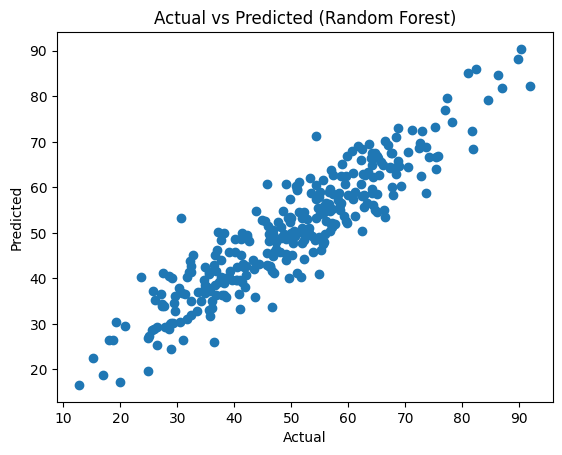

In [13]:
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

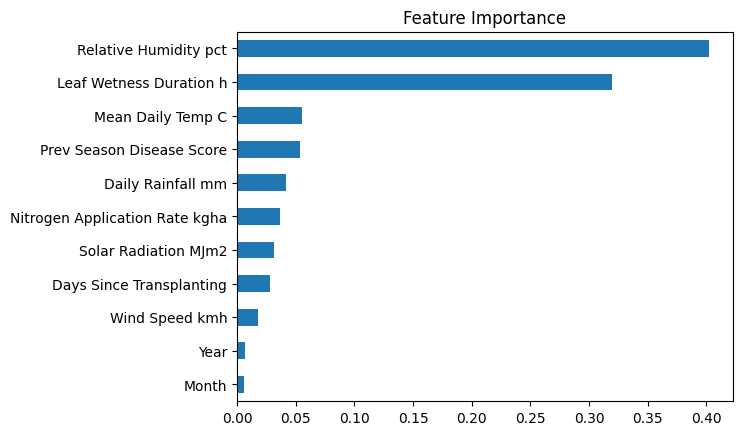

In [14]:
importances = best_rf.feature_importances_

feat_importance = pd.Series(importances, index=X.columns)
feat_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [15]:
# Store results
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Tuned Random Forest"],
    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_best)
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_best)
    ]
})

print(results)

                 Model        MSE  R2 Score
0    Linear Regression  27.282808  0.884444
1        Random Forest  36.396998  0.845840
2  Tuned Random Forest  36.447992  0.845624


In [16]:
# Best model based on R2 score
best_model = results.loc[results["R2 Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Linear Regression
MSE                 27.282808
R2 Score             0.884444
Name: 0, dtype: object


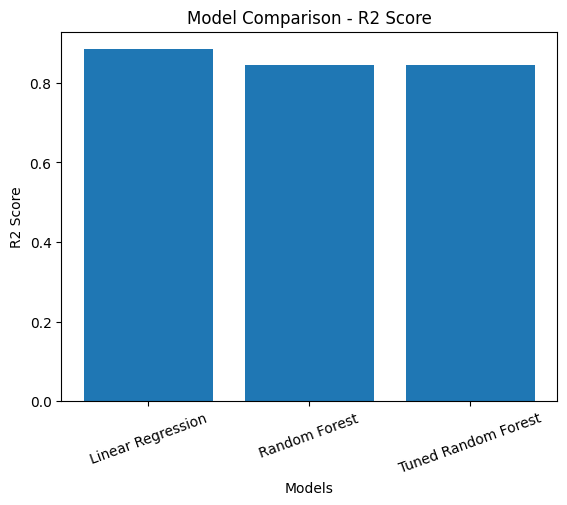

In [17]:
#R² Score Comparison
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results["Model"], results["R2 Score"])
plt.title("Model Comparison - R2 Score")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.show()

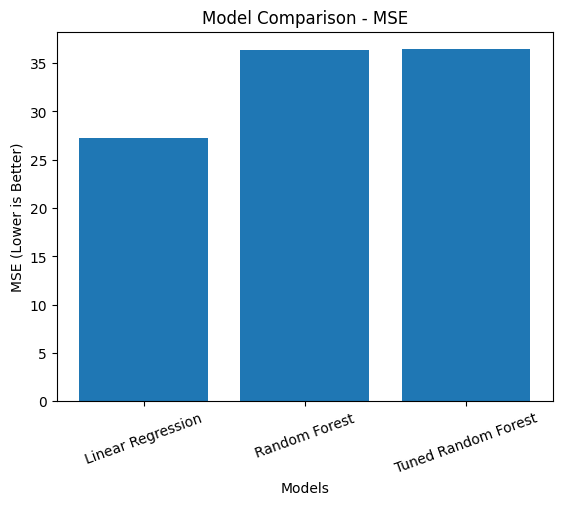

In [18]:
#MSE Comparison
plt.figure()
plt.bar(results["Model"], results["MSE"])
plt.title("Model Comparison - MSE")
plt.xlabel("Models")
plt.ylabel("MSE (Lower is Better)")
plt.xticks(rotation=20)
plt.show()

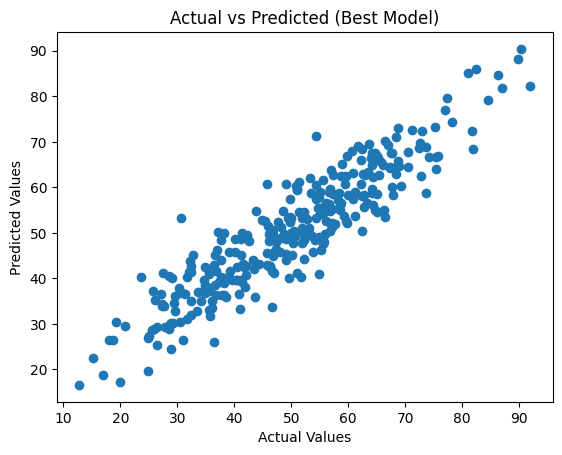

In [19]:
#Actual vs Predicted (Best Model)
plt.figure()
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Best Model)")
plt.show()